# Protocol Timing & Trace Feature Engineering

MultispeQ raw traces are stored as flat arrays without timing information.
This notebook uses the protocol definitions to reconstruct pulse timing,
then engineers new features from the time-resolved signals that are not
available in the standard computed columns.

**New features computed:**

| Feature | Description |
| --- | --- |
| `pirk_tau` | PIRK recovery time constant (ms) — exponential fit to post-illumination kinetics |
| `pirk_initial_slope` | Initial slope of PIRK recovery (first 10 ms) |
| `pam_fv_fm` | Variable fluorescence ratio from PAM-ABS trace |
| `pam_rise_time_ms` | Time from Fo to Fm peak (ms) |
| `pam_820_delta` | 820nm absorbance change during saturating pulse (P700 proxy) |

**Works both locally and on Databricks.**

In [4]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# src is at the repo root, one level up from advanced/
sys.path.insert(0, str(Path("..").resolve()))

from src.data import load_grebbedijk
from src.protocol import (
    deinterleave,
    generate_protocol_timing,
    get_protocol,
    segment_boundaries,
)

DATA = Path("..") / "data"

## Protocol timing

Load the protocol definition for UNZA_PIRK_DIRK_LightPotential_14 (ID 3517)
and compute pulse timing for each sub-protocol.

In [5]:
protocol = get_protocol(DATA, "3517")
timing = generate_protocol_timing(protocol, verbose=True)

PIRK               402 samples (1 det),  401 ms
PAM-ABS            660 samples (2 det),  659 ms
PAM-ABS-FR        4244 samples (2 det),  4243 ms


In [6]:
df = load_grebbedijk(DATA)
print(f"{len(df):,} measurements")
df.head(3)

3,681 measurements


,measurement_id,project_id,user_id,device_id,status,timestamp,latitude,longitude,plot_number,plant_measured,...,PIRK_amp_ambient,PIRK_amp_high,pirk_intensity,autogain_ch1_duration,autogain_ch1_intensity,autogain_ch1_value,autogain_ch2_duration,autogain_ch2_intensity,autogain_ch2_value,measurement_duration_sec
0,5621984,33338,142465,11:16:69:38,submitted,2025-08-14 06:09:47.297000+00:00,51.951985,5.632942,38,Plant 1_Extra,...,0.279,0.083,2000.0,10.0,-4294.0,47526.0,20.0,-596.0,49255.0,33.526
1,5621983,33338,142465,11:16:69:38,submitted,2025-08-14 06:10:40.511000+00:00,51.952878,5.634602,37,Plant 1_Extra,...,0.544,0.032,2000.0,10.0,-4294.0,45819.0,20.0,-596.0,49793.0,37.238
2,5621982,33338,142465,11:16:69:38,submitted,2025-08-14 06:11:23.515000+00:00,51.952888,5.634602,41,Plant 1_Extra,...,0.163,-0.001,2000.0,10.0,-4294.0,44589.0,20.0,-596.0,36753.0,33.703


## Parse raw traces locally

The `sample_raw` column is a JSON string containing the full MultispeQ output.
We extract the `data_raw` arrays for PIRK and PAM-ABS sub-protocols.

In [7]:
def extract_traces(sample_raw: str) -> dict[str, list[np.ndarray]]:
    """Extract data_raw arrays from sample_raw JSON, keyed by label."""
    parsed = json.loads(sample_raw)
    traces: dict[str, list[np.ndarray]] = {}
    for step in parsed[0]["set"]:
        label = step.get("label", "")
        data_raw = step.get("data_raw")
        if data_raw and len(data_raw) > 0:
            traces.setdefault(label, []).append(np.array(data_raw, dtype=float))
    return traces


# Parse one measurement to verify
sample = extract_traces(df.iloc[0]["sample_raw"])
for label, arrs in sample.items():
    sizes = [len(a) for a in arrs]
    print(f"{label:15s}  {len(arrs)} repeat(s),  sizes={sizes}")

PIRK             2 repeat(s),  sizes=[402, 402]
PAM-ABS          2 repeat(s),  sizes=[660, 660]
PAM-ABS-FR       1 repeat(s),  sizes=[4244]


## PIRK traces with timing

PIRK (Post-Illumination Rise in fluorescence Kinetics) measures the re-reduction
of the plastoquinone pool after a light pulse. The recovery kinetics encode
information about cyclic electron flow and thylakoid conductance.

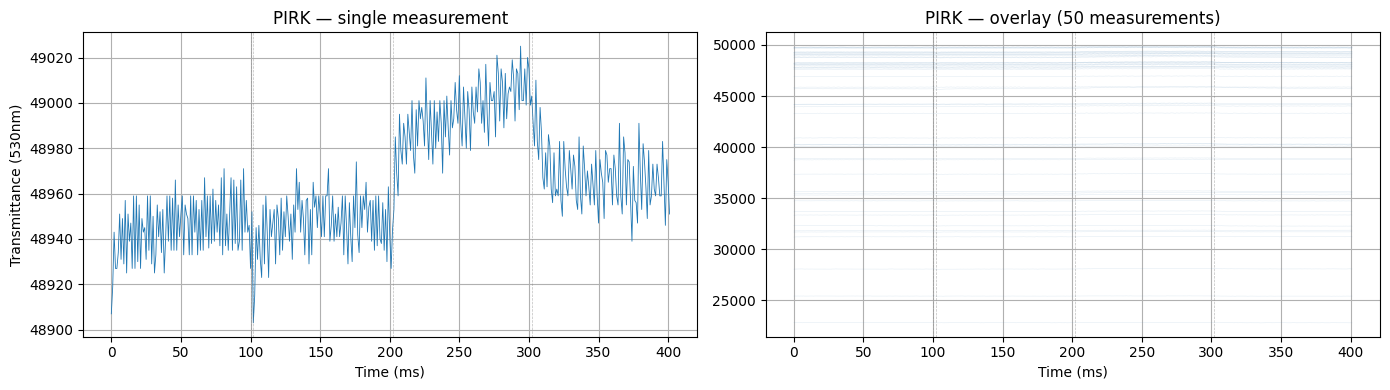

In [8]:
t_pirk = timing["PIRK"]["time_ms"]
bounds = segment_boundaries(timing["PIRK"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Single trace
trace = sample["PIRK"][0]
ax1.plot(t_pirk, trace, linewidth=0.6)
for b in bounds:
    ax1.axvline(b, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Transmittance (530nm)")
ax1.set_title("PIRK — single measurement")
ax1.grid(True)

# Overlay 50 measurements
for i in range(min(50, len(df))):
    try:
        tr = extract_traces(df.iloc[i]["sample_raw"])["PIRK"][0]
        ax2.plot(t_pirk, tr, alpha=0.15, linewidth=0.4, color="steelblue")
    except Exception:
        continue
for b in bounds:
    ax2.axvline(b, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)
ax2.set_xlabel("Time (ms)")
ax2.set_title("PIRK — overlay (50 measurements)")
ax2.grid(True)

plt.tight_layout()
plt.show()

## PAM-ABS traces with timing

PAM-ABS uses two interleaved detectors:
- **Even indices** → chlorophyll fluorescence (Fo, Fm, Fv/Fm)
- **Odd indices** → 820nm transmittance (P700 redox state)

The `pulse_distance` is between each sub-pulse, so same-detector pulses
are 2× the pulse_distance apart.

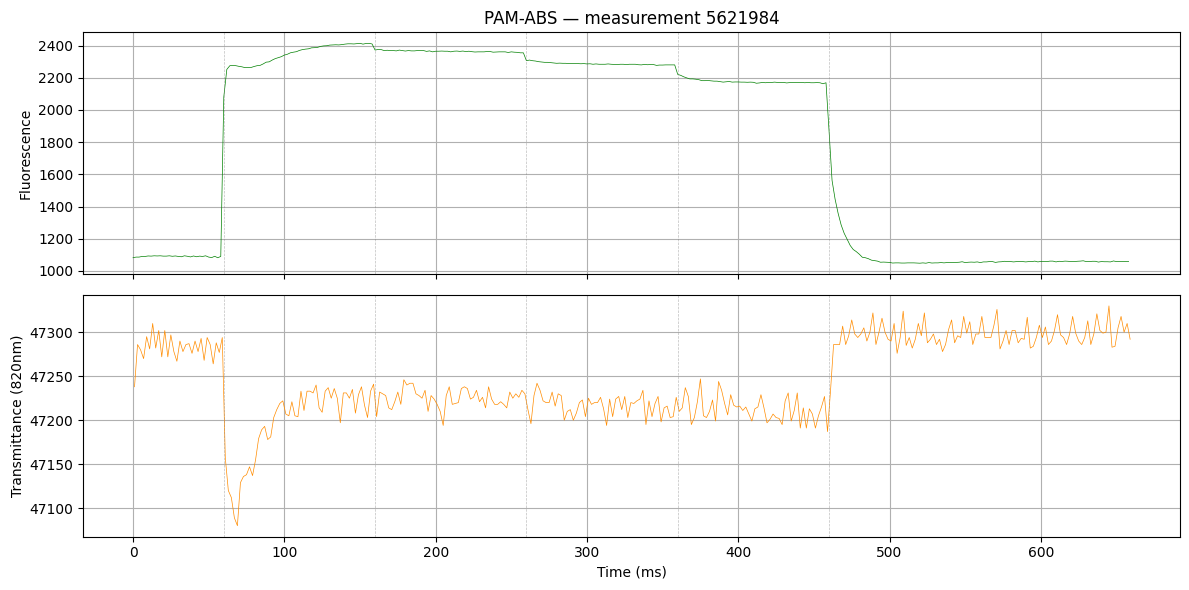

In [9]:
t_pam = timing["PAM-ABS"]["time_ms"]
pam_bounds = segment_boundaries(timing["PAM-ABS"])
raw_pam = sample["PAM-ABS"][0]
fluo, t820 = deinterleave(raw_pam, n_detectors=2)
t_fluo = t_pam[0::2]
t_t820 = t_pam[1::2]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(t_fluo, fluo, linewidth=0.5, color="green")
ax1.set_ylabel("Fluorescence")
ax1.set_title(f"PAM-ABS — measurement {df.iloc[0]['measurement_id']}")
ax1.grid(True)

ax2.plot(t_t820, t820, linewidth=0.5, color="darkorange")
ax2.set_ylabel("Transmittance (820nm)")
ax2.set_xlabel("Time (ms)")
ax2.grid(True)

for b in pam_bounds:
    ax1.axvline(b, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)
    ax2.axvline(b, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Feature engineering

Extract kinetic features from the time-resolved traces that are **not** in
the standard computed columns.

### PIRK features
- `pirk_tau`: exponential recovery time constant (ms)
- `pirk_initial_slope`: slope of the first 10 ms after light-off

### PAM-ABS features
- `pam_fv_fm`: (Fm - Fo) / Fm from the fluorescence trace
- `pam_rise_time_ms`: time from Fo to Fm peak
- `pam_820_delta`: absorbance change at 820nm during the saturating pulse (P700)

In [10]:
def _exp_decay(t: np.ndarray, a: float, tau: float, c: float) -> np.ndarray:
    """Exponential decay: a * exp(-t/tau) + c."""
    return a * np.exp(-t / tau) + c


def pirk_features(
    trace: np.ndarray, time_ms: np.ndarray, v_arrays: list
) -> dict[str, float]:
    """Extract PIRK kinetic features."""
    # Segment boundaries from v_arrays[0]: [baseline, transition, recovery...]
    seg_pulses = [int(x) for x in v_arrays[0]]
    baseline_end = seg_pulses[0]
    recovery_start = baseline_end + seg_pulses[1]  # after the transition pulse

    # Normalize to baseline mean
    baseline = np.mean(trace[1 : min(10, baseline_end)])
    trace_norm = (trace - baseline) / baseline * 1000  # per-mille change

    # Initial slope: first 10 pulses after recovery start
    slope_end = min(recovery_start + 10, len(trace))
    t_slope = time_ms[recovery_start:slope_end] - time_ms[recovery_start]
    y_slope = trace_norm[recovery_start:slope_end]
    if len(t_slope) > 1:
        initial_slope = float(np.polyfit(t_slope, y_slope, 1)[0])
    else:
        initial_slope = np.nan

    # Exponential fit for tau
    t_rec = time_ms[recovery_start:] - time_ms[recovery_start]
    y_rec = trace_norm[recovery_start:]
    try:
        popt, _ = curve_fit(
            _exp_decay,
            t_rec,
            y_rec,
            p0=[y_rec[0], 50.0, y_rec[-1]],
            maxfev=2000,
        )
        tau = abs(float(popt[1]))
    except (RuntimeError, ValueError):
        tau = np.nan

    return {"pirk_tau": tau, "pirk_initial_slope": initial_slope}


def pam_features(
    trace: np.ndarray, time_ms: np.ndarray, v_arrays: list
) -> dict[str, float]:
    """Extract PAM-ABS kinetic features."""
    fluo, t820 = deinterleave(trace, 2)
    t_fluo = time_ms[0::2]

    # Segment pulses for PAM-ABS from v_arrays[1]
    seg_pulses = [int(x) for x in v_arrays[1]]
    fo_end = seg_pulses[0]  # first segment = measuring light (Fo)

    # Fo = minimum in the baseline segment
    fo = float(np.min(fluo[max(1, fo_end - int(fo_end * 0.1)) : fo_end]))

    # Fm = max of the first saturating pulse segment
    sat_end = fo_end + seg_pulses[1]
    fm = float(np.max(fluo[fo_end:sat_end]))

    fv_fm = (fm - fo) / fm if fm > 0 else np.nan

    # Rise time: time from Fo to Fm peak
    fm_idx = fo_end + int(np.argmax(fluo[fo_end:sat_end]))
    rise_time_ms = float(t_fluo[fm_idx] - t_fluo[max(0, fo_end - 1)])

    # 820nm delta: absorbance change during saturating pulse
    t820_baseline = float(np.mean(t820[max(1, fo_end - 5) : fo_end]))
    t820_sat = float(np.mean(t820[fo_end : fo_end + seg_pulses[1]]))
    delta_820 = (
        (t820_sat - t820_baseline) / t820_baseline * 1000
        if t820_baseline > 0
        else np.nan
    )

    return {
        "pam_fv_fm": round(fv_fm, 5),
        "pam_rise_time_ms": round(rise_time_ms, 2),
        "pam_820_delta": round(delta_820, 3),
    }


# Test on single measurement
v_arr = protocol["v_arrays"]
print("PIRK:", pirk_features(sample["PIRK"][0], timing["PIRK"]["time_ms"], v_arr))
print("PAM: ", pam_features(sample["PAM-ABS"][0], timing["PAM-ABS"]["time_ms"], v_arr))

PIRK: {'pirk_tau': 56.74034905789654, 'pirk_initial_slope': 0.07592099097741568}
PAM:  {'pam_fv_fm': 0.55178, 'pam_rise_time_ms': 92.0, 'pam_820_delta': -1.787}


## Batch feature extraction

In [11]:
rows = []
t_pirk = timing["PIRK"]["time_ms"]
t_pam = timing["PAM-ABS"]["time_ms"]

for idx in range(len(df)):
    row = df.iloc[idx]
    try:
        traces = extract_traces(row["sample_raw"])
        feats = {"measurement_id": row["measurement_id"]}
        # Ambient repeat (index 0)
        if "PIRK" in traces and len(traces["PIRK"]) > 0:
            feats.update(pirk_features(traces["PIRK"][0], t_pirk, v_arr))
        if "PAM-ABS" in traces and len(traces["PAM-ABS"]) > 0:
            feats.update(pam_features(traces["PAM-ABS"][0], t_pam, v_arr))
        rows.append(feats)
    except Exception:
        continue

features = pd.DataFrame(rows)
print(f"Extracted features for {len(features):,} / {len(df):,} measurements")
features.describe().round(3)

/tmp/ipykernel_68095/527654563.py:3: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-t / tau) + c
/tmp/ipykernel_68095/527654563.py:32: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
/tmp/ipykernel_68095/527654563.py:3: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-t / tau) + c


Extracted features for 3,681 / 3,681 measurements


,pirk_tau,pirk_initial_slope,pam_fv_fm,pam_rise_time_ms,pam_820_delta
count,3.681000e+03,3681.000,3681.000,3681.000,3681.000
mean,1.561377e+05,0.042,0.341,86.262,-2.449
std,9.194402e+05,0.038,0.131,18.472,1.126
min,3.000000e-03,-0.621,0.040,2.000,-46.069
25%,4.652700e+01,0.022,0.230,84.000,-2.991
50%,5.068100e+01,0.041,0.330,92.000,-2.489
75%,5.574900e+01,0.060,0.455,98.000,-1.907
max,1.293542e+07,0.841,0.645,100.000,7.780


## Analysis: kinetic features by genotype

In [12]:
# Merge features with measurement data
df_feat = df.merge(features, on="measurement_id")

# Genotype means
geno_means = (
    df_feat.groupby("Genotype")[
        [
            "pirk_tau",
            "pirk_initial_slope",
            "pam_fv_fm",
            "pam_rise_time_ms",
            "pam_820_delta",
        ]
    ]
    .mean()
    .sort_values("pirk_tau")
)
print(f"{len(geno_means)} genotypes")
geno_means.round(3)

48 genotypes


,pirk_tau,pirk_initial_slope,pam_fv_fm,pam_rise_time_ms,pam_820_delta
Genotype,,,,,
IVP97-079-9,46.924,0.045,0.365,93.139,-2.240
RH87-607-111,55.343,0.042,0.342,84.152,-3.101
IVP10-272-26,24024.424,0.048,0.327,88.000,-2.507
IVP92-030-14,26384.475,0.046,0.357,87.873,-2.454
RH09-308-12,32685.363,0.038,0.300,80.720,-1.902
IVP05-124-20,39782.830,0.038,0.350,87.513,-2.905
RH87-565-102,44237.306,0.044,0.345,86.658,-2.502
RH14-496-2,65729.456,0.036,0.354,84.456,-2.808
RH09-222-7,67520.934,0.050,0.347,86.101,-2.342


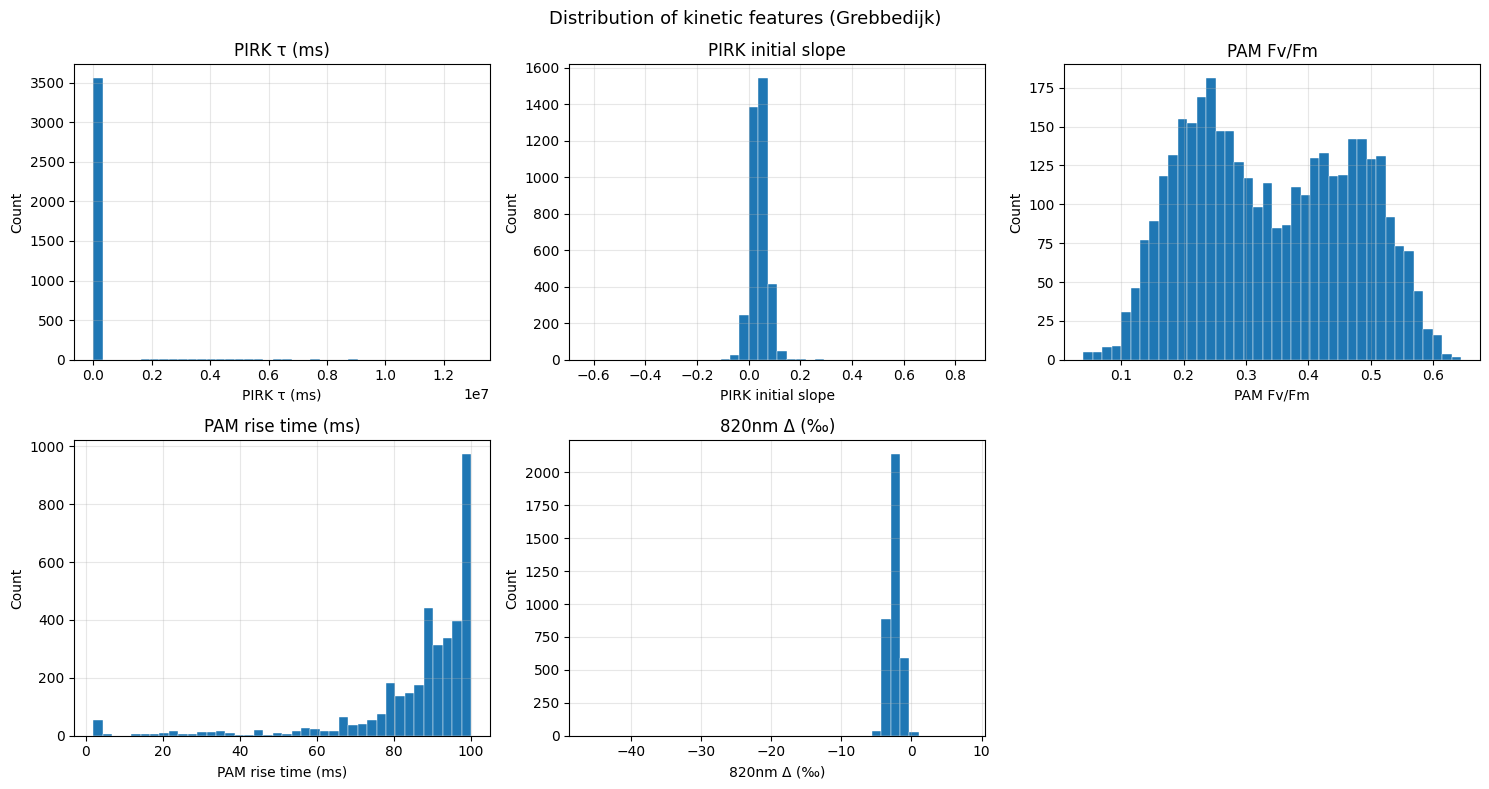

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

feat_cols = [
    "pirk_tau",
    "pirk_initial_slope",
    "pam_fv_fm",
    "pam_rise_time_ms",
    "pam_820_delta",
]
feat_labels = [
    "PIRK \u03c4 (ms)",
    "PIRK initial slope",
    "PAM Fv/Fm",
    "PAM rise time (ms)",
    "820nm \u0394 (\u2030)",
]

for i, (col, label) in enumerate(zip(feat_cols, feat_labels)):
    ax = axes[i]
    vals = df_feat[col].dropna()
    ax.hist(vals, bins=40, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle("Distribution of kinetic features (Grebbedijk)", fontsize=13)
plt.tight_layout()
plt.show()

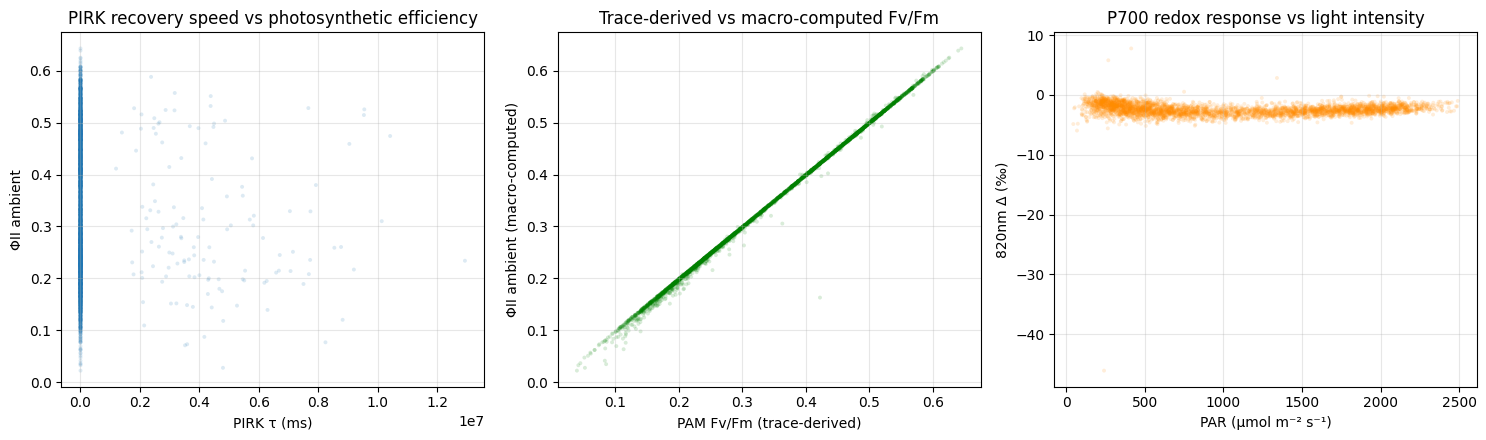

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# PIRK tau vs Phi2
mask = df_feat["pirk_tau"].notna() & df_feat["phi2_ambient"].notna()
ax1.scatter(
    df_feat.loc[mask, "pirk_tau"],
    df_feat.loc[mask, "phi2_ambient"],
    alpha=0.15,
    s=8,
    edgecolors="none",
)
ax1.set_xlabel("PIRK \u03c4 (ms)")
ax1.set_ylabel("\u03a6II ambient")
ax1.set_title("PIRK recovery speed vs photosynthetic efficiency")
ax1.grid(True, alpha=0.3)

# PAM Fv/Fm vs computed phi2
mask = df_feat["pam_fv_fm"].notna() & df_feat["phi2_ambient"].notna()
ax2.scatter(
    df_feat.loc[mask, "pam_fv_fm"],
    df_feat.loc[mask, "phi2_ambient"],
    alpha=0.15,
    s=8,
    edgecolors="none",
    color="green",
)
ax2.set_xlabel("PAM Fv/Fm (trace-derived)")
ax2.set_ylabel("\u03a6II ambient (macro-computed)")
ax2.set_title("Trace-derived vs macro-computed Fv/Fm")
ax2.grid(True, alpha=0.3)

# 820nm delta vs PAR
mask = df_feat["pam_820_delta"].notna() & df_feat["PAR"].notna()
ax3.scatter(
    df_feat.loc[mask, "PAR"],
    df_feat.loc[mask, "pam_820_delta"],
    alpha=0.15,
    s=8,
    edgecolors="none",
    color="darkorange",
)
ax3.set_xlabel("PAR (\u00b5mol m\u207b\u00b2 s\u207b\u00b9)")
ax3.set_ylabel("820nm \u0394 (\u2030)")
ax3.set_title("P700 redox response vs light intensity")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Genotype ranking by kinetic features

Rank genotypes by their PIRK recovery speed and fluorescence characteristics.
Faster PIRK recovery (lower tau) may indicate more efficient cyclic electron flow.

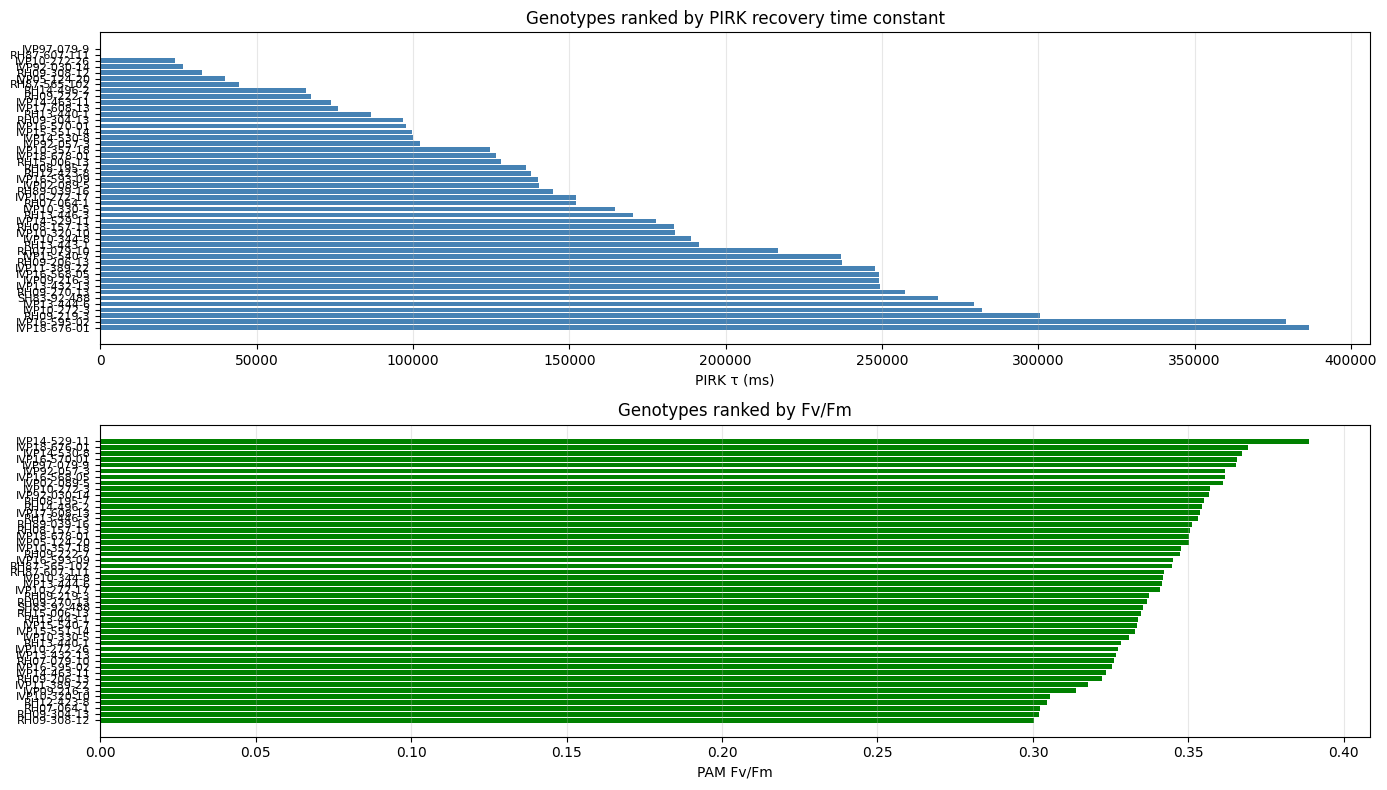

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

geno_sorted = geno_means.sort_values("pirk_tau")

ax1.barh(range(len(geno_sorted)), geno_sorted["pirk_tau"], color="steelblue")
ax1.set_yticks(range(len(geno_sorted)))
ax1.set_yticklabels(geno_sorted.index, fontsize=8)
ax1.set_xlabel("PIRK \u03c4 (ms)")
ax1.set_title("Genotypes ranked by PIRK recovery time constant")
ax1.grid(True, alpha=0.3, axis="x")
ax1.invert_yaxis()

geno_sorted2 = geno_means.sort_values("pam_fv_fm", ascending=False)
ax2.barh(range(len(geno_sorted2)), geno_sorted2["pam_fv_fm"], color="green")
ax2.set_yticks(range(len(geno_sorted2)))
ax2.set_yticklabels(geno_sorted2.index, fontsize=8)
ax2.set_xlabel("PAM Fv/Fm")
ax2.set_title("Genotypes ranked by Fv/Fm")
ax2.grid(True, alpha=0.3, axis="x")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## Light behavior: ambient vs high-light kinetics

Compare PIRK recovery and PAM fluorescence between the two repeats
(ambient light and high light at 2500 \u00b5mol) to visualize how
the photosynthetic apparatus responds to a sudden increase in light.

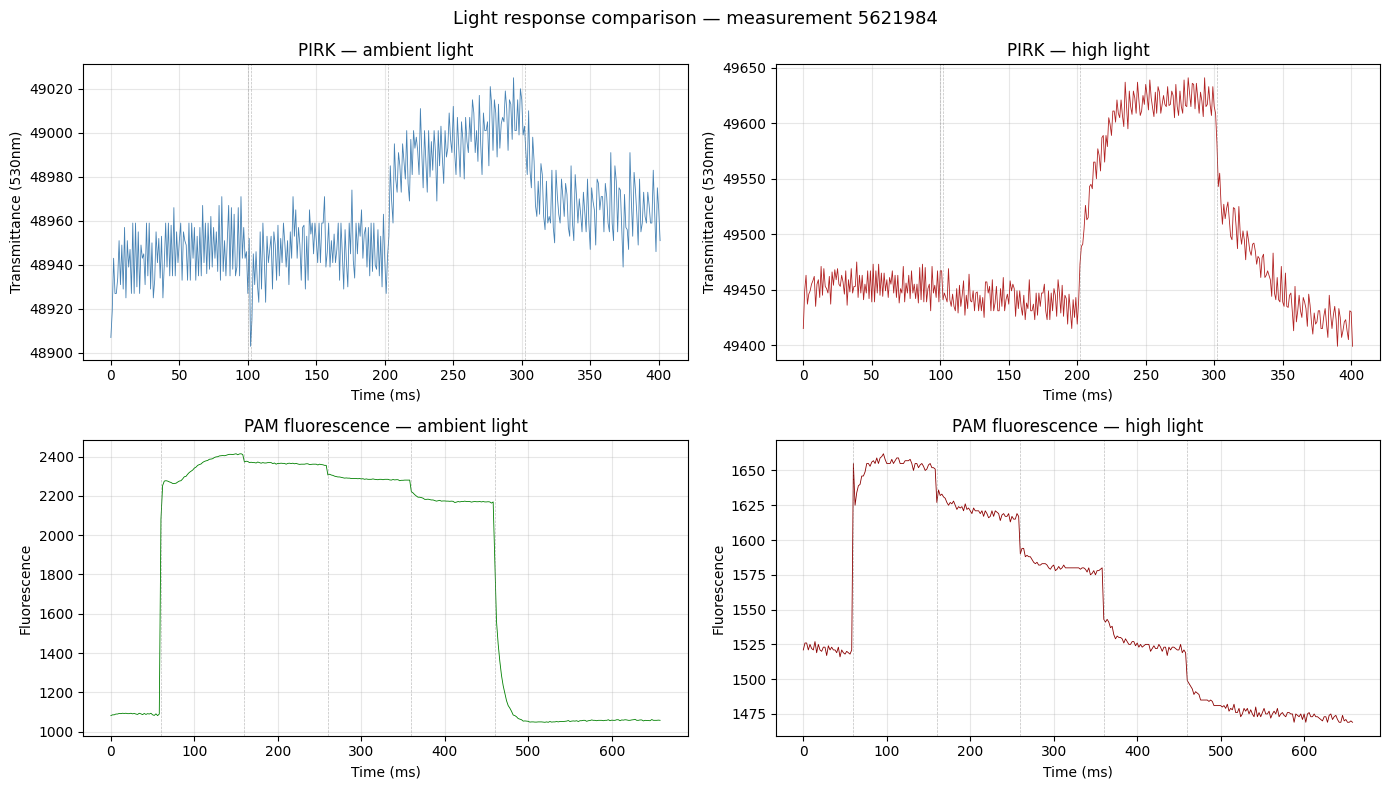

In [16]:
# Pick a single measurement for detailed comparison
traces_example = extract_traces(df.iloc[0]["sample_raw"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# PIRK: ambient vs high light
for i, (condition, color) in enumerate(
    [("ambient", "steelblue"), ("high", "firebrick")]
):
    if i < len(traces_example.get("PIRK", [])):
        tr = traces_example["PIRK"][i]
        axes[0, i].plot(t_pirk, tr, linewidth=0.6, color=color)
        for b in segment_boundaries(timing["PIRK"]):
            axes[0, i].axvline(b, color="grey", lw=0.5, ls="--", alpha=0.5)
        axes[0, i].set_title(f"PIRK — {condition} light")
        axes[0, i].set_xlabel("Time (ms)")
        axes[0, i].set_ylabel("Transmittance (530nm)")
        axes[0, i].grid(True, alpha=0.3)

# PAM-ABS: ambient vs high light (fluorescence channel)
for i, (condition, color) in enumerate([("ambient", "green"), ("high", "darkred")]):
    if i < len(traces_example.get("PAM-ABS", [])):
        raw = traces_example["PAM-ABS"][i]
        fluo_ch = deinterleave(raw, 2)[0]
        t_fl = timing["PAM-ABS"]["time_ms"][0::2]
        axes[1, i].plot(t_fl, fluo_ch, linewidth=0.6, color=color)
        for b in segment_boundaries(timing["PAM-ABS"]):
            axes[1, i].axvline(b, color="grey", lw=0.5, ls="--", alpha=0.5)
        axes[1, i].set_title(f"PAM fluorescence — {condition} light")
        axes[1, i].set_xlabel("Time (ms)")
        axes[1, i].set_ylabel("Fluorescence")
        axes[1, i].grid(True, alpha=0.3)

plt.suptitle(
    f"Light response comparison — measurement {df.iloc[0]['measurement_id']}",
    fontsize=13,
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_68095/527654563.py:32: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
/tmp/ipykernel_68095/527654563.py:3: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-t / tau) + c
/tmp/ipykernel_68095/527654563.py:3: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-t / tau) + c


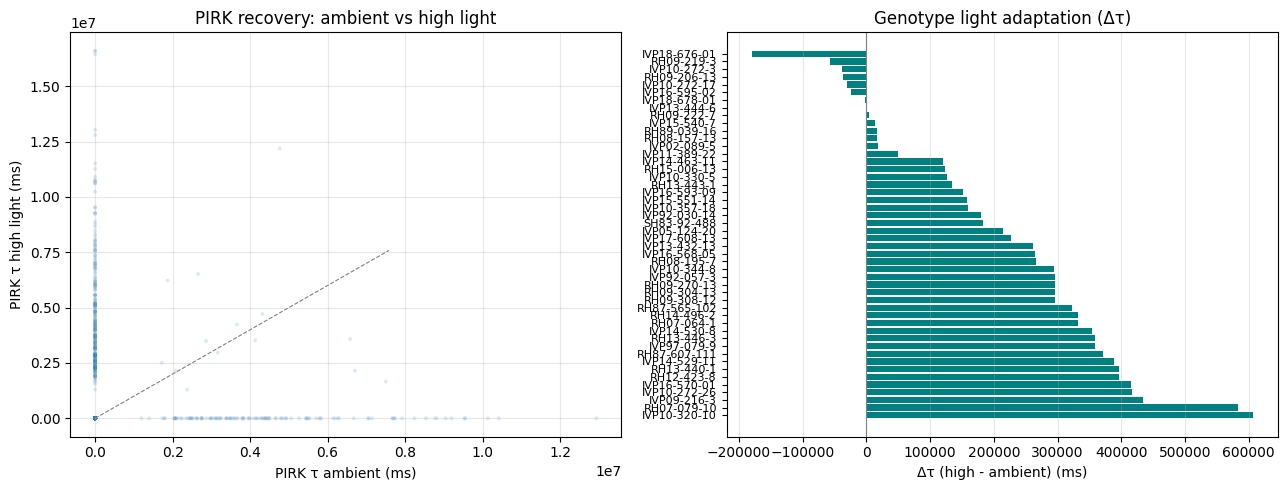

In [17]:
# Extract features for both repeats and compute high-ambient delta
rows_hl = []
for idx in range(len(df)):
    row = df.iloc[idx]
    try:
        traces = extract_traces(row["sample_raw"])
        pirk_list = traces.get("PIRK", [])
        pam_list = traces.get("PAM-ABS", [])
        if len(pirk_list) < 2 or len(pam_list) < 2:
            continue
        f_amb = pirk_features(pirk_list[0], t_pirk, v_arr)
        f_high = pirk_features(pirk_list[1], t_pirk, v_arr)
        rows_hl.append(
            {
                "measurement_id": row["measurement_id"],
                "pirk_tau_ambient": f_amb["pirk_tau"],
                "pirk_tau_high": f_high["pirk_tau"],
                "pirk_tau_delta": f_high["pirk_tau"] - f_amb["pirk_tau"],
            }
        )
    except Exception:
        continue

hl_df = pd.DataFrame(rows_hl)
hl_df = df[["measurement_id", "Genotype", "PAR"]].merge(hl_df, on="measurement_id")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

mask = hl_df["pirk_tau_ambient"].notna() & hl_df["pirk_tau_high"].notna()
ax1.scatter(
    hl_df.loc[mask, "pirk_tau_ambient"],
    hl_df.loc[mask, "pirk_tau_high"],
    alpha=0.15,
    s=8,
    edgecolors="none",
)
lims = [
    0,
    max(
        hl_df.loc[mask, "pirk_tau_ambient"].quantile(0.99),
        hl_df.loc[mask, "pirk_tau_high"].quantile(0.99),
    ),
]
ax1.plot(lims, lims, "--", color="grey", linewidth=0.8)
ax1.set_xlabel("PIRK \u03c4 ambient (ms)")
ax1.set_ylabel("PIRK \u03c4 high light (ms)")
ax1.set_title("PIRK recovery: ambient vs high light")
ax1.grid(True, alpha=0.3)

geno_delta = hl_df.groupby("Genotype")["pirk_tau_delta"].mean().sort_values()
ax2.barh(range(len(geno_delta)), geno_delta.values, color="teal")
ax2.set_yticks(range(len(geno_delta)))
ax2.set_yticklabels(geno_delta.index, fontsize=8)
ax2.axvline(0, color="grey", linewidth=0.8)
ax2.set_xlabel("\u0394\u03c4 (high - ambient) (ms)")
ax2.set_title("Genotype light adaptation (\u0394\u03c4)")
ax2.grid(True, alpha=0.3, axis="x")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()